In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
dataset=pd.read_csv("/home/dsbatch2/Downloads/breastcancer1.csv")

In [4]:
dataset.sample(2)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
437,909220,B,14.04,15.98,89.78,611.2,0.08458,0.05895,0.03534,0.02944,...,15.66,21.58,101.2,750.0,0.1195,0.1252,0.1117,0.07453,0.2725,0.07234
70,859575,M,18.94,21.31,123.60,1130.0,0.09009,0.10290,0.10800,0.07951,...,24.86,26.58,165.9,1866.0,0.1193,0.2336,0.2687,0.17890,0.2551,0.06589


In [5]:
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              564 non-null    float64
 3   texture_mean             561 non-null    float64
 4   perimeter_mean           561 non-null    float64
 5   area_mean                564 non-null    float64
 6   smoothness_mean          566 non-null    float64
 7   compactness_mean         566 non-null    float64
 8   concavity_mean           566 non-null    float64
 9   concave points_mean      562 non-null    float64
 10  symmetry_mean            564 non-null    float64
 11  fractal_dimension_mean   564 non-null    float64
 12  radius_se                568 non-null    float64
 13  texture_se               568 non-null    float64
 14  perimeter_se             5

In [7]:
dataset.isna().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             8
area_mean                  5
smoothness_mean            3
compactness_mean           3
concavity_mean             3
concave points_mean        7
symmetry_mean              5
fractal_dimension_mean     5
radius_se                  1
texture_se                 1
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [28]:
columns = ["radius_mean", "texture_mean"]
for col in columns:
    m = dataset[col].mean()
    dataset[col] = dataset[col].fillna(m)
dataset.isna().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             8
area_mean                  5
smoothness_mean            3
compactness_mean           3
concavity_mean             3
concave points_mean        7
symmetry_mean              5
fractal_dimension_mean     5
radius_se                  1
texture_se                 1
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

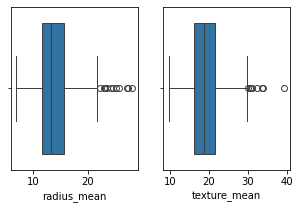

In [9]:
plt.figure(figsize=(5, 3))
plt.subplot(1, 2, 1)
sns.boxplot(x=dataset["radius_mean"])
plt.subplot(1, 2, 2)
sns.boxplot(x=dataset["texture_mean"])
plt.show()

In [10]:
dataset.shape

(569, 32)

In [12]:
dataset_cleaned = dataset

for col in columns:
    q1 = dataset[col].quantile(0.25)
    q3 = dataset[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    dataset_cleaned = dataset_cleaned[
        (dataset_cleaned[col] >= lower) & (dataset_cleaned[col] <= upper)]
dataset_cleaned.shape

(548, 32)

In [13]:
y = dataset_cleaned["diagnosis"]
x = dataset_cleaned[["radius_mean", "texture_mean"]]

In [16]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = list(range(1, 30))
accuracies = []

In [19]:
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    predictions = knn.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    accuracies.append(accuracy)

In [31]:
for k, acc in zip(k_values, accuracies):
    print(f"k={k}, accuracy={acc:.4f}")

best_k = k_values[accuracies.index(max(accuracies))]
print(f"Best k: {best_k}, Accuracy: {max(accuracies)*100:.2f}%")

k=1, accuracy=0.8182
k=2, accuracy=0.7909
k=3, accuracy=0.8364
k=4, accuracy=0.8545
k=5, accuracy=0.8727
k=6, accuracy=0.8636
k=7, accuracy=0.8545
k=8, accuracy=0.8455
k=9, accuracy=0.8455
k=10, accuracy=0.8545
k=11, accuracy=0.8727
k=12, accuracy=0.8545
k=13, accuracy=0.8545
k=14, accuracy=0.8455
k=15, accuracy=0.8545
k=16, accuracy=0.8455
k=17, accuracy=0.8455
k=18, accuracy=0.8273
k=19, accuracy=0.8364
k=20, accuracy=0.8455
k=21, accuracy=0.8364
k=22, accuracy=0.8364
k=23, accuracy=0.8364
k=24, accuracy=0.8455
k=25, accuracy=0.8455
k=26, accuracy=0.8364
k=27, accuracy=0.8273
k=28, accuracy=0.8273
k=29, accuracy=0.8273
Best k: 5, Accuracy: 87.273%


In [21]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)

In [24]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[58  4]
 [10 38]]


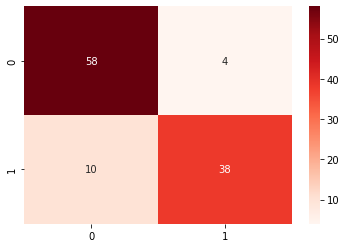

In [25]:
sns.heatmap(conf_matrix, annot=True, fmt="g", cmap="Reds")
plt.show()

In [26]:
print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))

Accuracy: 0.8727272727272727
Precision: 0.9047619047619048


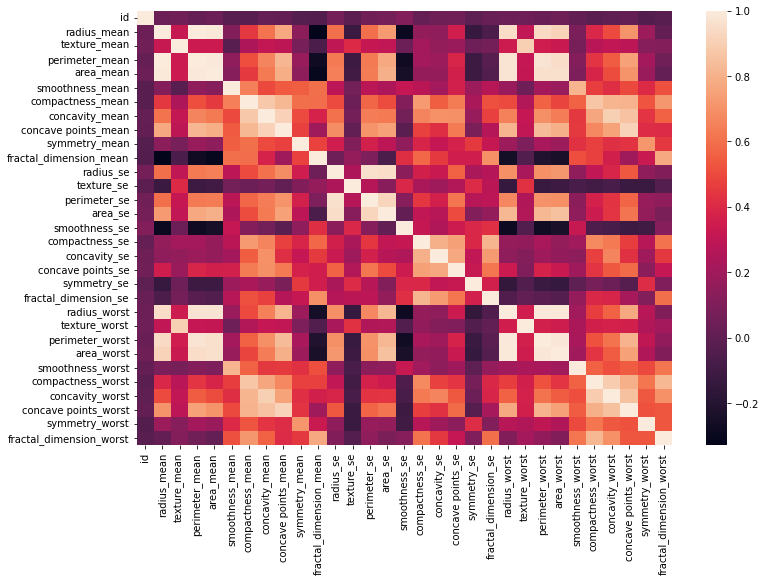

In [27]:
plt.figure(figsize=(12, 8))
sns.heatmap(dataset_cleaned.select_dtypes(exclude="object").corr())
plt.show()